In [22]:
import numpy as np
from numpy import random as nprnd
import random as rnd
import pandas as pd
import string as str
from math import *

#scipy stat
import scipy.stats as ss
from scipy import stats
from scipy.stats import linregress,norm, kurtosis, moment,iqr,binom, binomtest,gmean
from scipy.stats import expon,zscore,zmap
from scipy.stats import t,ttest_ind
from scipy.stats import f,f_oneway
from scipy.stats import boxcox
from scipy.stats import pearsonr
#scipy signals library
from scipy import signal
#scipy calculus library
import scipy.integrate as spi



#scipy chi
from scipy.stats import chi,chi2_contingency,chi2

import math

import os
import time

import csv

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.style as style
import seaborn as sns
# Pkg import Date Time
from datetime import datetime
from datetime import timedelta
from pandas.tseries.offsets import Hour, Minute
from pandas.tseries.offsets import Day, MonthEnd
import pytz
from pandas.tseries.frequencies import to_offset
#import arviz as az
import plotly
from sympy import symbols, Eq, solve
import re #extract cofficient

###################################################
'''sklearn'''
###################################################
# # Ordinary Least Squares
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.formula.api import ols
from statsmodels.stats.stattools import durbin_watson
from patsy import dmatrices

from zlib import crc32
import hashlib

###################################################
'''sklearn'''
###################################################
# model_selection
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import KFold, StratifiedKFold, StratifiedShuffleSplit
from sklearn.model_selection import learning_curve

# Multiclass
from sklearn.multiclass import OneVsOneClassifier

# Base
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.base import clone

# preprocessing
from sklearn.preprocessing import OrdinalEncoder,OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures

# pipeline
from sklearn.pipeline import Pipeline
from sklearn.pipeline import make_pipeline

# datasets
from sklearn.datasets import fetch_openml
from sklearn.datasets import make_blobs
from sklearn import datasets
from sklearn.datasets import make_classification
from sklearn.datasets import load_iris

# metrics
try:
    from sklearn.metrics import root_mean_squared_error
except ImportError:
    from sklearn.metrics import mean_squared_error
from sklearn.metrics import confusion_matrix,precision_score,\
                            recall_score,f1_score
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import ConfusionMatrixDisplay                         

# tree
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import DecisionTreeClassifier

# linear_model
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import SGDClassifier
from sklearn.linear_model import Ridge
from sklearn.linear_model import SGDRegressor
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.linear_model import LogisticRegression

from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

import tensorflow as tf
from tensorflow import keras

import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
import tarfile
import urllib.request
import tensorflow as tf
from tensorflow import keras
import sys
from copy import deepcopy
# =====================================


### Multiclass Classification or multinomial classifiers

1. Random Forest classifiers or naive Bayes classifiers are capable of handling multiple classes directly.
2. Support Vector Machine classifiers or Linear classifiers are strictly binary classifiers.
3. OvA ( One-vs-All)

### OvA:

In OvA, a binary classifier is trained for each class, where the positive class is the class of interest and the negative class is all other classes.

when you want to classify an image, you get the decision score from each classifier for that image and you select the class whose classifier outputs the highest score. This is called the one-versus-all (OvA) strategy
(also called one-versus-the-rest).

#### one-versus-one (OvO) strategy:

If there are N classes, you need to train 

 = N × (N – 1) / 2 classifiers

For MIST Let suppos you hae 4 Digit i.e. 0,1,2,3
Total classifire = 4*2/2 = 4

- Classifier 0: 0 vs. (1 + 2 + 3)
- Classifier 1: 1 vs. (0 + 2 + 3)
- Classifier 2: 2 vs. (1 + 0 + 3)
- Classifier 3: 3 vs. (1 + 2 + 0)

Suppose we have a multi-class classification problem with three classes: A, B, and C. We would train three binary classifiers:

- Classifier 1: A vs. (B + C)
- Classifier 2: B vs. (A + C)
- Classifier 3: C vs. (A + B)

MNIST problem, N = 10 (0 to 9) this means training 45 binary classifiers!

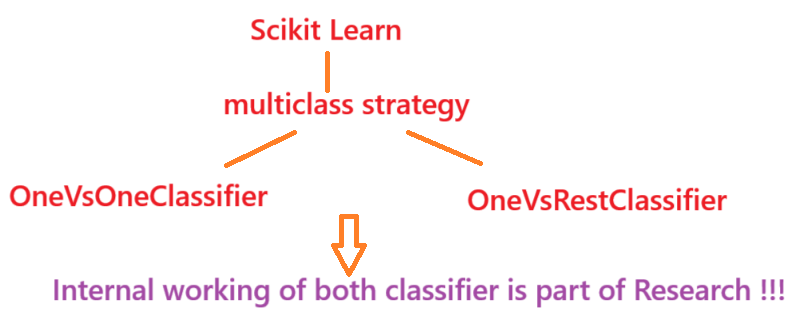


### Multiclass Strategy by using OneVsRestClassifier()

In [3]:
path = r'C:\Users\TODO\Desktop\Abhi\AI\AI\allDataSet\KaggelDataset\work\Iris.csv'
df = pd.read_csv(path)
df.columns
df['Species'].value_counts()

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

In [4]:
X = df.loc[:,['SepalLengthCm','SepalWidthCm','PetalLengthCm','PetalWidthCm']].to_numpy()
y = df['Species'].map({'Iris-setosa':0,'Iris-versicolor':1,'Iris-virginica':2}).to_numpy()
X.shape,y.shape,type(X),type(y)

((150, 4), (150,), numpy.ndarray, numpy.ndarray)

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, shuffle=True, random_state=0)

In [6]:
sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train)


SGDClassifier(random_state=42)

In [7]:
y_predicted = sgd_clf.predict(X_test)

In [8]:

dfSgd = pd.DataFrame({'Predicted':y_predicted, 'Actual':y_test,'Compair':y_predicted == y_test})


In [9]:
dfSgd['Compair'].value_counts()

Compair
True     48
False     2
Name: count, dtype: int64

In [ ]:
sgd_clf.classes_

array([0, 1, 2], dtype=int64)

### OneVsOneClassifier()

In [11]:
ovo_clf = OneVsOneClassifier(SGDClassifier(random_state=42))
ovo_clf.fit(X_train, y_train)
y_predicted_ovo = ovo_clf.predict(X_test)
dfOvo = pd.DataFrame({'Predicted':y_predicted_ovo, 'Actual':y_test,'Compair':y_predicted_ovo == y_test})
dfOvo['Compair'].value_counts()


Compair
True     33
False    17
Name: count, dtype: int64

In [13]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.astype(np.float64))
cross_val_score(sgd_clf, X_train_scaled, y_train, cv=3, scoring="accuracy")

array([0.85294118, 0.90909091, 0.90909091])

In [20]:
y_train_pred = cross_val_predict(sgd_clf, X_train_scaled, y_train, cv=3)
conf_mx = confusion_matrix(y_train, y_train_pred)
conf_mx, 'Total classes:',sgd_clf.classes_

(array([[33,  1,  0],
        [ 3, 22,  6],
        [ 0,  1, 34]], dtype=int64),
 'Total classes:',
 array([0, 1, 2], dtype=int64))

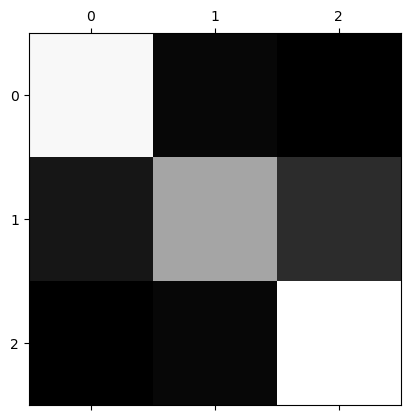

In [ ]:
# Greay Style plot
plt.matshow(conf_mx, cmap=plt.cm.gray)
plt.show()

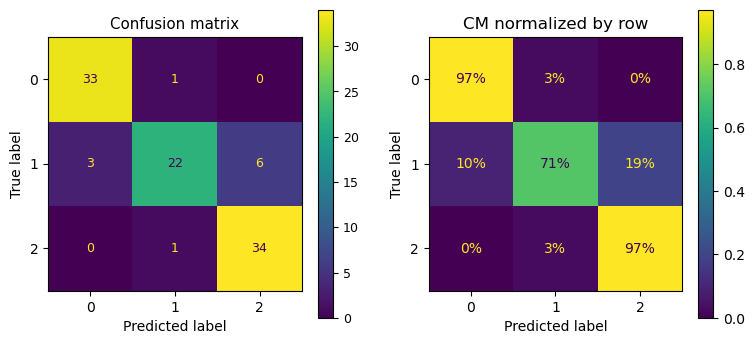

In [26]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(9, 4))
plt.rc('font', size=9)
#plot 1:
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred, ax=axs[0])
axs[0].set_title("Confusion matrix")
plt.rc('font', size=10)
#plot 2:
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred, ax=axs[1],
                                        normalize="true", values_format=".0%")
axs[1].set_title("CM normalized by row")
#save_fig("confusion_matrix_plot_1")
plt.show()